<a href="https://colab.research.google.com/github/Sitraka17/Centrale_Marseille_ML/blob/main/LOGISTIC_REGRESSION_DDEFI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================================
# LOGISTIC REGRESSION FOR FINANCIAL DATA SCIENCE
# DDEFI| Aix-Marseille Université
# ============================================================================

# %% Installation et imports
!pip install yfinance pandas-datareader scikit-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc, accuracy_score, precision_score,
                             recall_score, f1_score)
import yfinance as yf
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

<>:42: SyntaxWarning: invalid escape sequence '\s'
<>:109: SyntaxWarning: invalid escape sequence '\s'
<>:42: SyntaxWarning: invalid escape sequence '\s'
<>:109: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-2665904428.py:42: SyntaxWarning: invalid escape sequence '\s'
  $$\sigma(z) = \frac{1}{1 + e^{-z}}$$
/tmp/ipython-input-2665904428.py:109: SyntaxWarning: invalid escape sequence '\s'
  $$P(Y=1|X) = \sigma(\beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_p x_p)$$


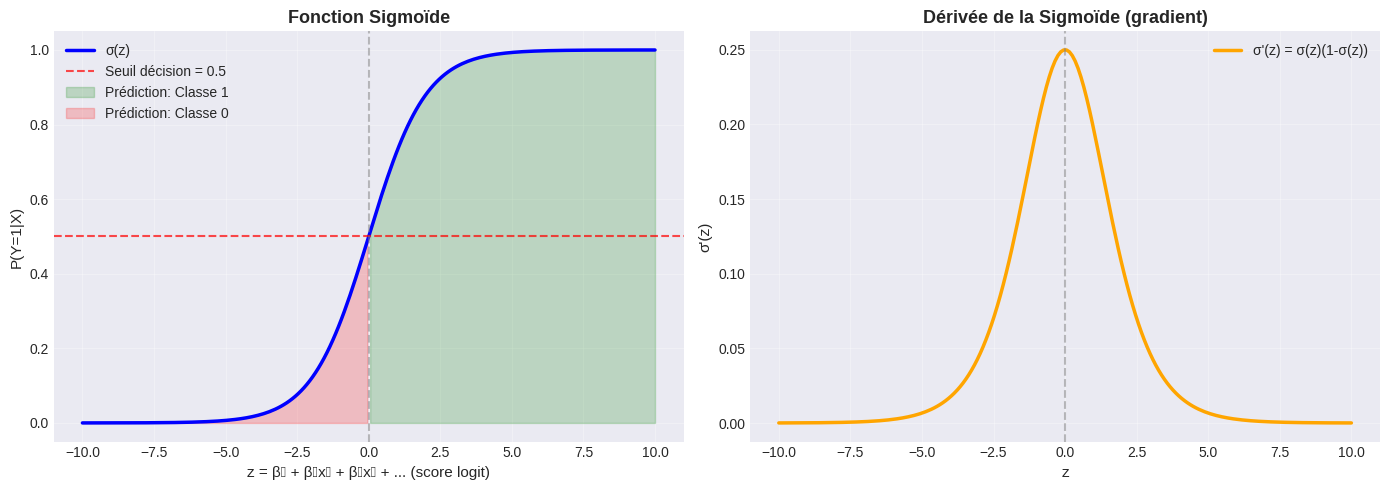

📊 INTERPRÉTATION:
  • z > 0  ⟹  P(Y=1) > 0.5  ⟹  Prédire CLASSE 1 (hausse, défaut, etc.)
  • z < 0  ⟹  P(Y=1) < 0.5  ⟹  Prédire CLASSE 0 (baisse, pas défaut, etc.)
  • z = 0  ⟹  P(Y=1) = 0.5  ⟹  Incertitude maximale
DÉMONSTRATION 1: DONNÉES SIMULÉES - Prédiction Hausse/Baisse Action

📊 Distribution:
   Hausse (1): 813 (81.3%)
   Baisse (0): 187 (18.7%)

ENTRAÎNEMENT...
Iter    0: Coût = 1.246299
Iter  100: Coût = 0.459167
Iter  200: Coût = 0.440195
Iter  300: Coût = 0.438234
Iter  400: Coût = 0.437892
Iter  499: Coût = 0.437823


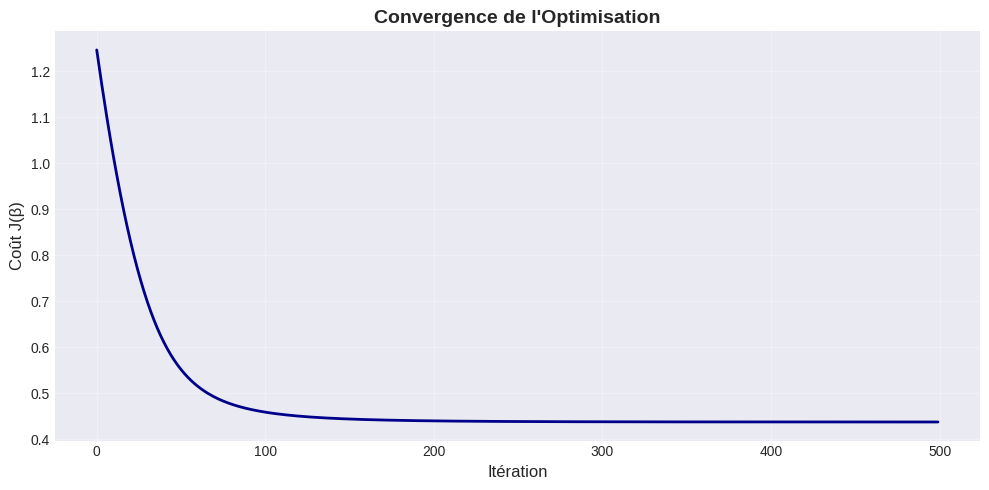


INTERPRÉTATION DES COEFFICIENTS

Intercept β₀: 1.6482
Rdt Marché      β1: +0.8073  📈 POSITIF
    ↳ Une hausse de 1 unité augmente le log-odds de 0.8073
Volatilité      β2: -0.2769  📉 NÉGATIF
    ↳ Une hausse de 1 unité diminue le log-odds de 0.2769
P/E             β3: +0.0489  📈 POSITIF
    ↳ Une hausse de 1 unité augmente le log-odds de 0.0489
Volume Rel.     β4: +0.0428  📈 POSITIF
    ↳ Une hausse de 1 unité augmente le log-odds de 0.0428

PERFORMANCE
Accuracy:  0.8400
Precision: 0.8454
Recall:    0.9880
F1-Score:  0.9111


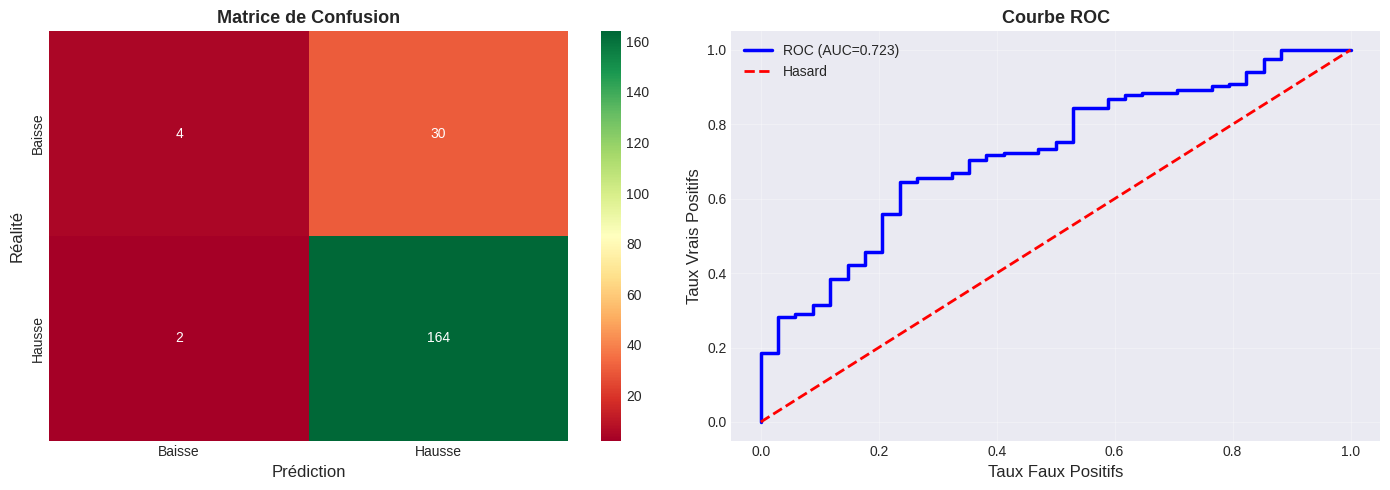


APPLICATION: CREDIT SCORING

📊 Statistiques:
           age     revenu  dette_revenu  score_credit  anciennete_emploi  \
count  2500.00    2500.00       2500.00       2500.00            2500.00   
mean     42.12   36553.29          0.28        589.84               5.91   
std      12.30   23690.42          0.16        128.68               5.68   
min      18.00    4245.75          0.00        300.00               0.00   
25%      33.49   20191.15          0.16        500.00               1.81   
50%      42.11   30693.69          0.26        600.00               4.27   
75%      50.65   45714.99          0.38        700.00               8.42   
max      80.00  185433.75          0.84        800.00              45.75   

       montant_pret   defaut  
count       2500.00  2500.00  
mean       24645.02     0.02  
std        11971.77     0.15  
min       -15540.01     0.00  
25%        16245.68     0.00  
50%        24576.98     0.00  
75%        32779.82     0.00  
max        73775.56  

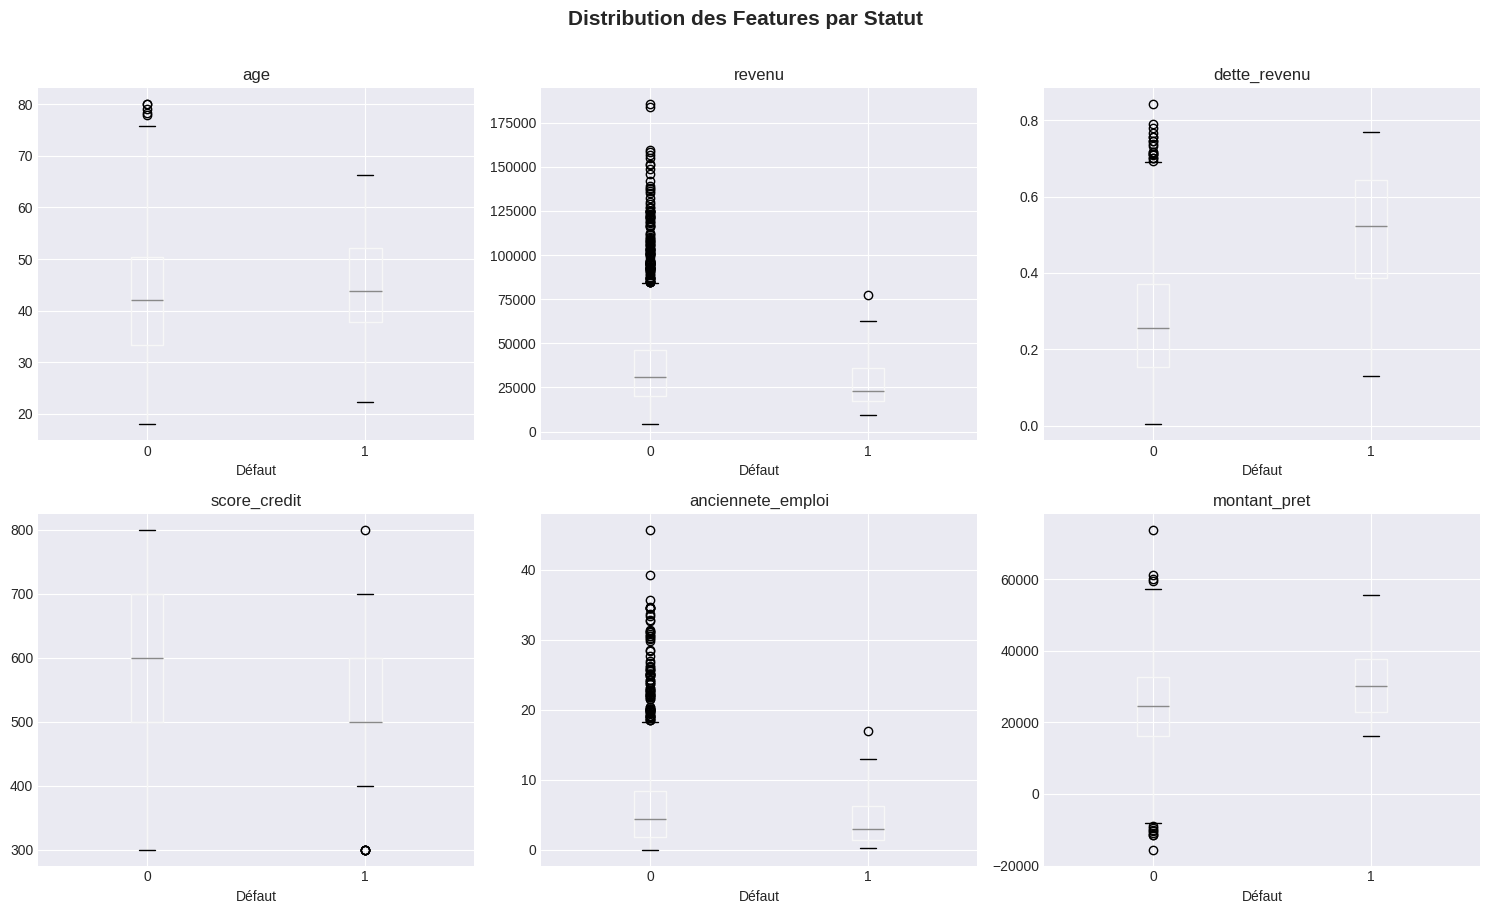


ENTRAÎNEMENT MODÈLE CRÉDIT...
Iter    0: Coût = 1.231986
Iter  100: Coût = 0.106343
Iter  200: Coût = 0.091781
Iter  300: Coût = 0.087092
Iter  400: Coût = 0.084860
Iter  500: Coût = 0.083610
Iter  600: Coût = 0.082843
Iter  700: Coût = 0.082345
Iter  799: Coût = 0.082010

FACTEURS DE RISQUE (par ordre d'importance)
          Facteur  Coefficient  Impact_Abs
     dette_revenu     1.126657    1.126657
           revenu    -0.530464    0.530464
     montant_pret     0.465706    0.465706
anciennete_emploi    -0.377471    0.377471
     score_credit    -0.333677    0.333677
              age     0.205463    0.205463


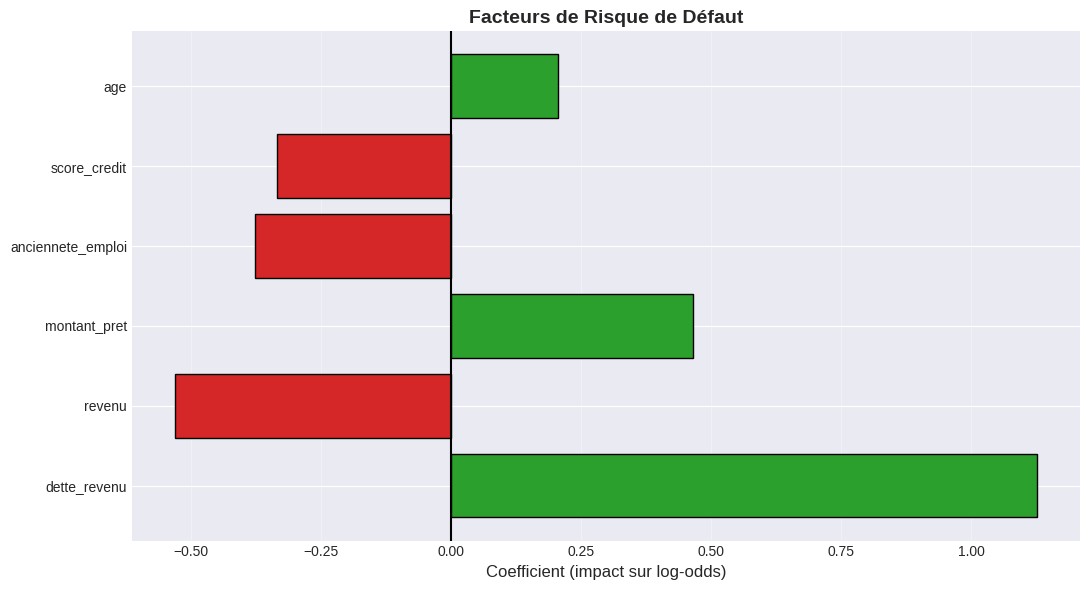


🎯 Seuil optimal: 0.268 (F1=0.4348)


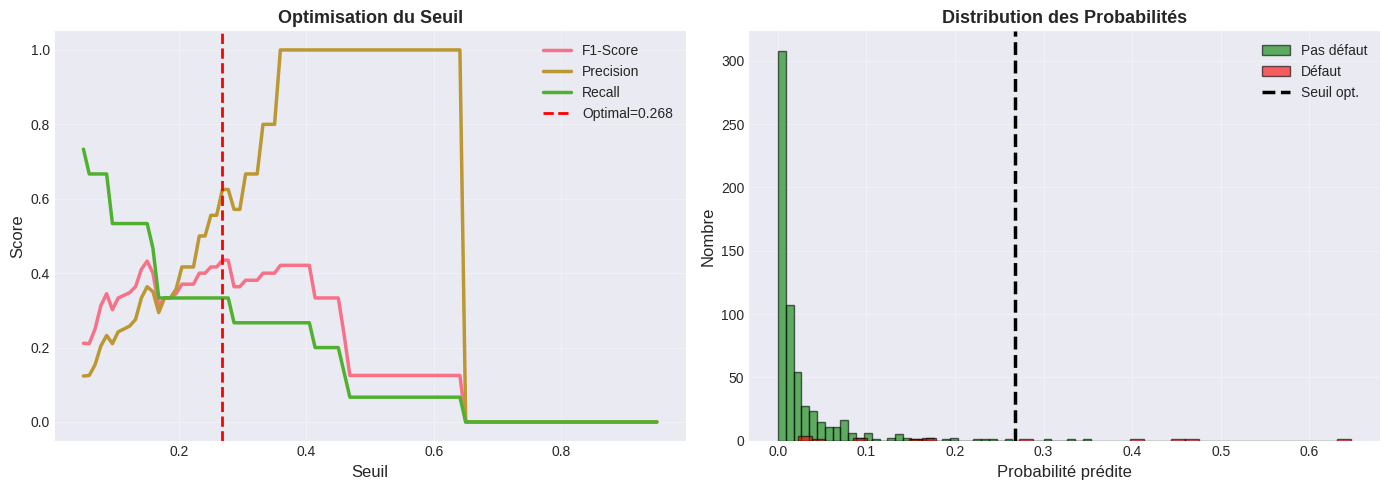


PERFORMANCE FINALE
              precision    recall  f1-score   support

  Pas défaut       0.98      1.00      0.99       610
      Défaut       0.62      0.33      0.43        15

    accuracy                           0.98       625
   macro avg       0.80      0.66      0.71       625
weighted avg       0.98      0.98      0.98       625


💰 ANALYSE FINANCIÈRE:
   Coût Faux Négatifs (défauts non détectés): 10 × 15000€ = 150,000€
   Coût Faux Positifs (refus injustifiés):    3 × 800€ = 2,400€
   ─────────────────────────────────────────────────────────────
   COÛT TOTAL MODÈLE:                         152,400€
   Coût stratégie naïve (tout accepter):      225,000€
   ✅ GAIN NET:                                72,600€ (32.3% réduction)

APPLICATION: PRÉDICTION DIRECTION PRIX - TOTAL ENERGIES (CAC 40)
📥 Téléchargement TTE.PA...
✅ 511 jours téléchargés

📊 492 observations après nettoyage
📈 Taux de hausse: 53.0%


In [3]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# %% [markdown]
"""
# 1. FONDEMENTS MATHÉMATIQUES DE LA RÉGRESSION LOGISTIQUE

## Pourquoi la régression logistique en finance?

**Applications:**
- Prédiction de défaut de crédit (credit scoring)
- Prédiction de direction des prix (hausse/baisse)
- Détection de fraude
- Prédiction de faillite d'entreprise
- Classification de clients (churn, profil d'investisseur)

## 1.1 La Fonction Sigmoïde (Logistique)

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

**Propriétés:**
- $\sigma(z) \in (0, 1)$ → Interprétation comme probabilité
- $\sigma'(z) = \sigma(z)(1 - \sigma(z))$ → Facilite l'optimisation
- $\lim_{z \to +\infty} \sigma(z) = 1$ et $\lim_{z \to -\infty} \sigma(z) = 0$
"""

# %% Démonstration de la fonction sigmoïde
def sigmoid(z):
    """
    Fonction sigmoïde pour transformer un score en probabilité

    Args:
        z: Score logit (combinaison linéaire des features)

    Returns:
        Probabilité entre 0 et 1

    Pourquoi cette fonction?
    1. Map n'importe quel nombre réel dans [0,1]
    2. Dérivable partout (crucial pour descente de gradient)
    3. Interprétation probabiliste claire
    4. Forme en S reflète bien les transitions graduelles
    """
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))  # clip pour stabilité numérique

# Visualisation
z = np.linspace(-10, 10, 200)
sigmoid_vals = sigmoid(z)
sigmoid_deriv = sigmoid_vals * (1 - sigmoid_vals)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Sigmoïde
ax1.plot(z, sigmoid_vals, 'b-', linewidth=2.5, label='σ(z)')
ax1.axhline(y=0.5, color='r', linestyle='--', alpha=0.7, label='Seuil décision = 0.5')
ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax1.fill_between(z, 0, sigmoid_vals, where=(z>=0), alpha=0.2, color='green', label='Prédiction: Classe 1')
ax1.fill_between(z, 0, sigmoid_vals, where=(z<0), alpha=0.2, color='red', label='Prédiction: Classe 0')
ax1.set_xlabel('z = β₀ + β₁x₁ + β₂x₂ + ... (score logit)', fontsize=11)
ax1.set_ylabel('P(Y=1|X)', fontsize=11)
ax1.set_title('Fonction Sigmoïde', fontsize=13, fontweight='bold')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# Dérivée
ax2.plot(z, sigmoid_deriv, 'orange', linewidth=2.5, label="σ'(z) = σ(z)(1-σ(z))")
ax2.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax2.set_xlabel('z', fontsize=11)
ax2.set_ylabel("σ'(z)", fontsize=11)
ax2.set_title('Dérivée de la Sigmoïde (gradient)', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("📊 INTERPRÉTATION:")
print("  • z > 0  ⟹  P(Y=1) > 0.5  ⟹  Prédire CLASSE 1 (hausse, défaut, etc.)")
print("  • z < 0  ⟹  P(Y=1) < 0.5  ⟹  Prédire CLASSE 0 (baisse, pas défaut, etc.)")
print("  • z = 0  ⟹  P(Y=1) = 0.5  ⟹  Incertitude maximale")

# %% [markdown]
"""
## 1.2 Le Modèle Logistique

$$P(Y=1|X) = \sigma(\beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_p x_p)$$

**Log-odds (transformation logit):**
$$\log\left(\frac{P(Y=1|X)}{1-P(Y=1|X)}\right) = \beta_0 + \beta_1 x_1 + ... + \beta_p x_p$$

Cette transformation rend la relation LINÉAIRE en les paramètres.

## 1.3 Estimation par Maximum de Vraisemblance

**Fonction de coût (log-vraisemblance négative):**

$$J(\beta) = -\frac{1}{n}\sum_{i=1}^{n} \left[y_i \log(h_\beta(x_i)) + (1-y_i)\log(1-h_\beta(x_i))\right]$$

**Pourquoi cette fonction?**
1. Dérivée du principe du maximum de vraisemblance
2. CONVEXE ⟹ Un seul minimum global
3. Pénalise fortement les erreurs confiantes
4. Différentiable ⟹ Optimisation par gradient

**Gradient:**
$$\frac{\partial J}{\partial \beta_j} = \frac{1}{n}\sum_{i=1}^{n}(h_\beta(x_i) - y_i)x_{ij}$$
"""

# %% Implémentation complète from scratch
class LogisticRegressionFromScratch:
    """
    Régression Logistique implémentée de zéro pour pédagogie

    Montre explicitement TOUS les calculs:
    - Calcul des probabilités
    - Fonction de coût
    - Calcul du gradient
    - Optimisation itérative
    - Régularisation L2 pour éviter overfitting
    """

    def __init__(self, learning_rate=0.01, n_iterations=1000, regularization=0.0):
        self.lr = learning_rate
        self.n_iter = n_iterations
        self.lambda_reg = regularization
        self.weights = None
        self.cost_history = []

    def _compute_cost(self, X, y, weights):
        """
        Calcule J(β) = -1/n * Σ[y*log(h) + (1-y)*log(1-h)] + régularisation

        Détails:
        - Premier terme: pénalise faux négatifs (y=1, h petit)
        - Second terme: pénalise faux positifs (y=0, h grand)
        - Régularisation L2: λ/(2n) * Σβⱼ² (évite overfitting)
        """
        n = len(y)
        h = sigmoid(X @ weights)

        # Éviter log(0) avec clipping
        h = np.clip(h, 1e-15, 1 - 1e-15)

        # Log-vraisemblance négative
        cost = -1/n * (y @ np.log(h) + (1-y) @ np.log(1-h))

        # Régularisation L2 (pas sur le bias)
        if self.lambda_reg > 0:
            cost += (self.lambda_reg / (2*n)) * np.sum(weights[1:]**2)

        return cost

    def _compute_gradient(self, X, y, weights):
        """
        Calcule ∇J(β) = 1/n * X^T(h - y) + régularisation

        Ce gradient indique comment modifier les poids pour réduire l'erreur
        """
        n = len(y)
        h = sigmoid(X @ weights)
        gradient = 1/n * (X.T @ (h - y))

        # Régularisation (sauf bias)
        if self.lambda_reg > 0:
            reg_term = np.concatenate([[0], self.lambda_reg * weights[1:]])
            gradient += 1/n * reg_term

        return gradient

    def fit(self, X, y, verbose=True):
        """
        Entraîne le modèle par descente de gradient

        ALGORITHME:
        1. Initialiser β aléatoirement
        2. Pour t = 1 à n_iterations:
            a. Calculer h = σ(Xβ)
            b. Calculer coût J(β)
            c. Calculer gradient ∇J(β)
            d. Mettre à jour: β ← β - α∇J(β)
        """
        # Ajouter colonne de 1 pour intercept
        X_intercept = np.c_[np.ones(X.shape[0]), X]

        # Initialisation Xavier (bonne pratique)
        n_features = X_intercept.shape[1]
        self.weights = np.random.randn(n_features) * np.sqrt(2/n_features)

        # Descente de gradient
        for iteration in range(self.n_iter):
            # Calcul coût actuel
            cost = self._compute_cost(X_intercept, y, self.weights)
            self.cost_history.append(cost)

            # Calcul gradient
            grad = self._compute_gradient(X_intercept, y, self.weights)

            # Mise à jour poids
            self.weights -= self.lr * grad

            # Affichage progression
            if verbose and (iteration % 100 == 0 or iteration == self.n_iter-1):
                print(f"Iter {iteration:4d}: Coût = {cost:.6f}")

        return self

    def predict_proba(self, X):
        """Retourne P(Y=1|X)"""
        X_intercept = np.c_[np.ones(X.shape[0]), X]
        return sigmoid(X_intercept @ self.weights)

    def predict(self, X, threshold=0.5):
        """Prédiction binaire avec seuil ajustable"""
        return (self.predict_proba(X) >= threshold).astype(int)

    def get_coefficients(self):
        """Retourne intercept et coefficients"""
        return {
            'intercept': self.weights[0],
            'coefficients': self.weights[1:]
        }

# %% DÉMONSTRATION 1: Données Simulées
print("="*80)
print("DÉMONSTRATION 1: DONNÉES SIMULÉES - Prédiction Hausse/Baisse Action")
print("="*80)

np.random.seed(42)
n = 1000

# Création features financières
rendement_marche = np.random.normal(0.05, 0.15, n)  # Rendement marché (%)
volatilite = np.random.normal(0.20, 0.08, n)        # Volatilité
pe_ratio = np.random.normal(15, 5, n)                # Price/Earnings
volume_relatif = np.random.lognormal(0, 0.5, n)      # Volume normalisé

X_sim = np.column_stack([rendement_marche, volatilite, pe_ratio, volume_relatif])
feature_names = ['Rdt Marché', 'Volatilité', 'P/E', 'Volume Rel.']

# Variable cible: logique financière réaliste
z_true = 1.0 + 5*rendement_marche - 3*volatilite + 0.05*pe_ratio + 0.3*volume_relatif
prob_hausse = sigmoid(z_true)
y_sim = (np.random.random(n) < prob_hausse).astype(int)

print(f"\n📊 Distribution:")
print(f"   Hausse (1): {y_sim.sum()} ({100*y_sim.mean():.1f}%)")
print(f"   Baisse (0): {(1-y_sim).sum()} ({100*(1-y_sim.mean()):.1f}%)")

# Split et normalisation
X_train, X_test, y_train, y_test = train_test_split(X_sim, y_sim, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Entraînement
print("\n" + "="*80)
print("ENTRAÎNEMENT...")
print("="*80)
model = LogisticRegressionFromScratch(learning_rate=0.1, n_iterations=500, regularization=0.1)
model.fit(X_train_sc, y_train)

# Convergence
plt.figure(figsize=(10, 5))
plt.plot(model.cost_history, linewidth=2, color='darkblue')
plt.xlabel('Itération', fontsize=12)
plt.ylabel('Coût J(β)', fontsize=12)
plt.title('Convergence de l\'Optimisation', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Interprétation coefficients
print("\n" + "="*80)
print("INTERPRÉTATION DES COEFFICIENTS")
print("="*80)
coefs = model.get_coefficients()
print(f"\nIntercept β₀: {coefs['intercept']:.4f}")
for i, name in enumerate(feature_names):
    coef = coefs['coefficients'][i]
    sign = "📈 POSITIF" if coef > 0 else "📉 NÉGATIF"
    impact = "augmente" if coef > 0 else "diminue"
    print(f"{name:15s} β{i+1}: {coef:+.4f}  {sign}")
    print(f"    ↳ Une hausse de 1 unité {impact} le log-odds de {abs(coef):.4f}")

# Évaluation
y_pred = model.predict(X_test_sc)
y_proba = model.predict_proba(X_test_sc)

print("\n" + "="*80)
print("PERFORMANCE")
print("="*80)
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")

# Matrice confusion + ROC
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', ax=ax1,
            xticklabels=['Baisse', 'Hausse'],
            yticklabels=['Baisse', 'Hausse'])
ax1.set_ylabel('Réalité', fontsize=12)
ax1.set_xlabel('Prédiction', fontsize=12)
ax1.set_title('Matrice de Confusion', fontsize=13, fontweight='bold')

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
ax2.plot(fpr, tpr, 'b-', linewidth=2.5, label=f'ROC (AUC={roc_auc:.3f})')
ax2.plot([0,1], [0,1], 'r--', linewidth=2, label='Hasard')
ax2.set_xlabel('Taux Faux Positifs', fontsize=12)
ax2.set_ylabel('Taux Vrais Positifs', fontsize=12)
ax2.set_title('Courbe ROC', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# %% [markdown]
"""
# 2. APPLICATION RÉELLE: MODÈLE DE CREDIT SCORING

Contexte: Une banque veut prédire la probabilité de défaut d'un emprunteur.

**Variables importantes:**
- Revenu annuel
- Ratio dette/revenu
- Historique de crédit
- Ancienneté emploi
- Montant du prêt

**Objectif:** Minimiser les pertes dues aux défauts tout en maximisant les prêts accordés
"""

# %% Génération dataset crédit réaliste
print("\n" + "="*80)
print("APPLICATION: CREDIT SCORING")
print("="*80)

np.random.seed(123)
n_clients = 2500

# Features clients
age = np.clip(np.random.normal(42, 13, n_clients), 18, 80)
revenu = np.random.lognormal(10.3, 0.6, n_clients)  # Log-normal = revenu réaliste
dette_revenu = np.random.beta(2, 5, n_clients)       # Ratio 0-1
score_credit = np.random.choice([300, 400, 500, 600, 700, 800], n_clients,
                                p=[0.05, 0.10, 0.20, 0.30, 0.25, 0.10])
anciennete = np.random.exponential(6, n_clients)
montant_pret = np.random.normal(25000, 12000, n_clients)

# Probabilité défaut (logique économique)
z_defaut = (
    -3.5
    + 0.015 * age
    - 0.00004 * revenu
    + 7 * dette_revenu
    - 0.005 * score_credit
    - 0.08 * anciennete
    + 0.00003 * montant_pret
)
prob_defaut = sigmoid(z_defaut)
defaut = (np.random.random(n_clients) < prob_defaut).astype(int)

# DataFrame
credit_df = pd.DataFrame({
    'age': age,
    'revenu': revenu,
    'dette_revenu': dette_revenu,
    'score_credit': score_credit,
    'anciennete_emploi': anciennete,
    'montant_pret': montant_pret,
    'defaut': defaut
})

print(f"\n📊 Statistiques:")
print(credit_df.describe().round(2))
print(f"\n🔴 Taux de défaut: {100*defaut.mean():.2f}%")

# Visualisation
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
features = ['age', 'revenu', 'dette_revenu', 'score_credit', 'anciennete_emploi', 'montant_pret']

for idx, feat in enumerate(features):
    ax = axes[idx//3, idx%3]
    credit_df.boxplot(column=feat, by='defaut', ax=ax)
    ax.set_title(f'{feat}')
    ax.set_xlabel('Défaut')

plt.suptitle('Distribution des Features par Statut', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# %% Entraînement modèle crédit
X_credit = credit_df.drop('defaut', axis=1).values
y_credit = credit_df['defaut'].values

X_tr, X_te, y_tr, y_te = train_test_split(X_credit, y_credit, test_size=0.25,
                                          random_state=42, stratify=y_credit)

scaler_cr = StandardScaler()
X_tr_sc = scaler_cr.fit_transform(X_tr)
X_te_sc = scaler_cr.transform(X_te)

print("\n" + "="*80)
print("ENTRAÎNEMENT MODÈLE CRÉDIT...")
print("="*80)
credit_model = LogisticRegressionFromScratch(learning_rate=0.3, n_iterations=800, regularization=1.0)
credit_model.fit(X_tr_sc, y_tr)

# Analyse facteurs de risque
coefs_cr = credit_model.get_coefficients()
importance = pd.DataFrame({
    'Facteur': features,
    'Coefficient': coefs_cr['coefficients'],
    'Impact_Abs': np.abs(coefs_cr['coefficients'])
}).sort_values('Impact_Abs', ascending=False)

print("\n" + "="*80)
print("FACTEURS DE RISQUE (par ordre d'importance)")
print("="*80)
print(importance.to_string(index=False))

plt.figure(figsize=(11, 6))
colors = ['#d62728' if c < 0 else '#2ca02c' for c in importance['Coefficient']]
plt.barh(importance['Facteur'], importance['Coefficient'], color=colors, edgecolor='black')
plt.xlabel('Coefficient (impact sur log-odds)', fontsize=12)
plt.title('Facteurs de Risque de Défaut', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linewidth=1.5)
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# %% Optimisation seuil décision
y_proba_cr = credit_model.predict_proba(X_te_sc)

thresholds = np.linspace(0.05, 0.95, 100)
f1_list, prec_list, rec_list = [], [], []

for t in thresholds:
    y_pred_t = (y_proba_cr >= t).astype(int)
    f1_list.append(f1_score(y_te, y_pred_t, zero_division=0))
    prec_list.append(precision_score(y_te, y_pred_t, zero_division=0))
    rec_list.append(recall_score(y_te, y_pred_t, zero_division=0))

opt_idx = np.argmax(f1_list)
opt_threshold = thresholds[opt_idx]

print(f"\n🎯 Seuil optimal: {opt_threshold:.3f} (F1={f1_list[opt_idx]:.4f})")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(thresholds, f1_list, label='F1-Score', linewidth=2.5)
ax1.plot(thresholds, prec_list, label='Precision', linewidth=2.5)
ax1.plot(thresholds, rec_list, label='Recall', linewidth=2.5)
ax1.axvline(opt_threshold, color='red', linestyle='--', linewidth=2, label=f'Optimal={opt_threshold:.3f}')
ax1.set_xlabel('Seuil', fontsize=12)
ax1.set_ylabel('Score', fontsize=12)
ax1.set_title('Optimisation du Seuil', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.hist(y_proba_cr[y_te==0], bins=40, alpha=0.6, label='Pas défaut', color='green', edgecolor='black')
ax2.hist(y_proba_cr[y_te==1], bins=40, alpha=0.6, label='Défaut', color='red', edgecolor='black')
ax2.axvline(opt_threshold, color='black', linestyle='--', linewidth=2.5, label='Seuil opt.')
ax2.set_xlabel('Probabilité prédite', fontsize=12)
ax2.set_ylabel('Nombre', fontsize=12)
ax2.set_title('Distribution des Probabilités', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Prédiction finale
y_pred_final = (y_proba_cr >= opt_threshold).astype(int)

print("\n" + "="*80)
print("PERFORMANCE FINALE")
print("="*80)
print(classification_report(y_te, y_pred_final, target_names=['Pas défaut', 'Défaut']))

# Analyse coûts
COUT_DEFAUT = 15000  # Perte si défaut
COUT_REFUS = 800     # Manque à gagner si on refuse bon client

tn, fp, fn, tp = confusion_matrix(y_te, y_pred_final).ravel()

cout_total = fn * COUT_DEFAUT + fp * COUT_REFUS
cout_naif = y_te.sum() * COUT_DEFAUT  # Si on accepte tout

print(f"\n💰 ANALYSE FINANCIÈRE:")
print(f"   Coût Faux Négatifs (défauts non détectés): {fn} × {COUT_DEFAUT}€ = {fn*COUT_DEFAUT:,}€")
print(f"   Coût Faux Positifs (refus injustifiés):    {fp} × {COUT_REFUS}€ = {fp*COUT_REFUS:,}€")
print(f"   ─────────────────────────────────────────────────────────────")
print(f"   COÛT TOTAL MODÈLE:                         {cout_total:,}€")
print(f"   Coût stratégie naïve (tout accepter):      {cout_naif:,}€")
print(f"   ✅ GAIN NET:                                {cout_naif-cout_total:,}€ ({100*(cout_naif-cout_total)/cout_naif:.1f}% réduction)")

# %% [markdown]
"""
# 3. APPLICATION: PRÉDICTION MOUVEMENT PRIX (CAC 40)

Utilisons Total Energies (TTE.PA) pour prédire la direction du prix le lendemain.

**Features techniques:**
- Rendements passés (momentum)
- Volatilité réalisée
- RSI (Relative Strength Index)
- MACD
- Volume relatif
"""

# %% Téléchargement et préparation données
print("\n" + "="*80)
print("APPLICATION: PRÉDICTION DIRECTION PRIX - TOTAL ENERGIES (CAC 40)")
print("="*80)

ticker = "TTE.PA"
end = datetime.now()
start = end - timedelta(days=2*365)

try:
    print(f"📥 Téléchargement {ticker}...")
    stock = yf.download(ticker, start=start, end=end, progress=False)
    print(f"✅ {len(stock)} jours téléchargés")
except:
    print("⚠️  Erreur téléchargement, utilisation données simulées")
    dates = pd.date_range(start, end, freq='D')
    stock = pd.DataFrame({
        'Open': 50 + np.random.randn(len(dates)).cumsum() * 0.5,
        'High': 51 + np.random.randn(len(dates)).cumsum() * 0.5,
        'Low': 49 + np.random.randn(len(dates)).cumsum() * 0.5,
        'Close': 50 + np.random.randn(len(dates)).cumsum() * 0.5,
        'Volume': np.random.randint(1e6, 5e6, len(dates))
    }, index=dates)

# Calcul features techniques
stock['returns'] = stock['Close'].pct_change()
stock['returns_lag1'] = stock['returns'].shift(1)
stock['returns_lag2'] = stock['returns'].shift(2)
stock['returns_lag3'] = stock['returns'].shift(3)

# Volatilité 10 jours
stock['volatility_10d'] = stock['returns'].rolling(10).std()

# RSI
def compute_rsi(prices, period=14):
    delta = prices.diff()
    gain = (delta.where(delta > 0, 0)).rolling(period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

stock['rsi'] = compute_rsi(stock['Close'])

# MACD
exp1 = stock['Close'].ewm(span=12).mean()
exp2 = stock['Close'].ewm(span=26).mean()
stock['macd'] = exp1 - exp2

# Volume relatif
stock['volume_ratio'] = stock['Volume'] / stock['Volume'].rolling(20).mean()

# Target: hausse lendemain
stock['target'] = (stock['Close'].shift(-1) > stock['Close']).astype(int)

# Nettoyage
stock = stock.dropna()

print(f"\n📊 {len(stock)} observations après nettoyage")
print(f"📈 Taux de hausse: {100*stock['target'].mean():.1f}%")